# Unimodal Cross-Modal Comparison: Analysis & Figures

## Disclaimer: This notebook was constructed with assistance from Gemini 3.1 Pro for code completion, debugging, and graph styling.

## Setup

In [1]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings('ignore')

In [2]:
BASELINE_CSV  = 'evaluation/baseline_iou_all.csv'
VISUAL_CSV    = 'evaluation/visual/unimodal_visual_flat.csv'
TEXTUAL_CSV   = 'evaluation/textual/unimodal_textual_flat.csv'
OUTPUT_DIR    = 'evaluation/crossmodal'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Constants & Mappings

In [3]:
IMG_NICE_NAMES = {
    'jpeg_filter': 'JPEG Compression', 'pixelate': 'Pixelation',
    'defocus_blur': 'Defocus Blur', 'motion_blur': 'Motion Blur',
    'gaussian_noise': 'Gaussian Noise',
    'fog_filter': 'Fog Overlay', 'snow_filter': 'Snow Overlay',
    'contrast': 'Contrast', 'elastic': 'Elastic Transform',
    'cutout': 'BB-Aware Cutout',
    'false_color': 'False Color', 'grayscale': 'Grayscale Blend',
}
IMG_CATEGORY_MAP = {
    'jpeg_filter': 'Digital', 'pixelate': 'Digital',
    'defocus_blur': 'Blur', 'motion_blur': 'Blur',
    'gaussian_noise': 'Noise',
    'false_color': 'Color', 'grayscale': 'Color', 'contrast': 'Color',
    'elastic': 'Geometric', 'cutout': 'Geometric',
    'snow_filter': 'Weather', 'fog_filter': 'Weather',
}
IMG_RETAINED = {'jpeg_filter', 'pixelate', 'defocus_blur', 'motion_blur',
                'gaussian_noise', 'fog_filter'}

TXT_NICE_NAMES = {
    'fragmentation': 'Fragmentation', 'character_noise': 'Character Noise',
    'ata_saliency': 'Lexical Saliency', 'homophone': 'Homophone',
    'synonym': 'Synonym',
}
TXT_CATEGORY_MAP = {
    'fragmentation': 'Orthographic', 'character_noise': 'Orthographic',
    'ata_saliency': 'Orthographic',
    'homophone': 'Semantic', 'synonym': 'Semantic',
}
LABEL_LEVEL = ['fragmentation', 'character_noise', 'ata_saliency',
               'homophone', 'synonym']

SCENE_COLORS  = {'Isolated': '#4878A8', 'Clustered': '#E8913A', 'Mixed': '#59A668'}
SCENE_MARKERS = {'Isolated': 'o', 'Clustered': 's', 'Mixed': '^'}
SCENE_ORDER   = ['Isolated', 'Clustered', 'Mixed']

MODALITY_COLORS  = {'Image': '#e41a1c', 'Text': '#377eb8'}
MODALITY_MARKERS = {'Image': 's', 'Text': 'D'}


def style_ax(ax, grid_major=True, grid_minor=False):
    """Apply shared axis styling matching prior notebooks."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    if grid_major:
        ax.yaxis.grid(True, which='major', ls='-', lw=0.4, alpha=0.5)
        ax.xaxis.grid(False)
    if grid_minor:
        ax.yaxis.grid(True, which='minor', ls=':', lw=0.3, alpha=0.3)

## Load Data

In [4]:
bl = pd.read_csv(BASELINE_CSV)
bl = bl.rename(columns={'iou': 'baseline_iou'})
bl_lookup = bl.set_index(['scene_type', 'sample_id'])['baseline_iou'].to_dict()
bl_means = bl.groupby('scene_type')['baseline_iou'].mean().to_dict()
bl_overall = bl['baseline_iou'].mean()
print(f'Baseline: {len(bl)} samples, overall mean IoU = {bl_overall:.5f}')
print(f'Per-scene: {bl_means}')

Baseline: 750 samples, overall mean IoU = 0.84875
Per-scene: {'Clustered': 0.84142396, 'Isolated': 0.92264948, 'Mixed': 0.7821761199999999}


In [5]:
df_img_all = pd.read_csv(VISUAL_CSV)
df_img_all['modality'] = 'Image'
df_img_all['category'] = df_img_all['corruption'].map(IMG_CATEGORY_MAP)
if 'baseline_iou' not in df_img_all.columns:
    df_img_all['baseline_iou'] = df_img_all.apply(
        lambda r: bl_lookup.get((r.scene_type, r.sample_id), np.nan), axis=1)

print(f'Visual rows (all 12): {len(df_img_all):,}')
print(f'Corruptions: {sorted(df_img_all.corruption.unique())}')

Visual rows (all 12): 45,000
Corruptions: ['contrast', 'cutout', 'defocus_blur', 'elastic', 'false_color', 'fog_filter', 'gaussian_noise', 'grayscale', 'jpeg_filter', 'motion_blur', 'pixelate', 'snow_filter']


In [6]:
df_txt_all = pd.read_csv(TEXTUAL_CSV)
df_txt_all['modality'] = 'Text'
df_txt_all['category'] = df_txt_all['corruption'].map(TXT_CATEGORY_MAP)
if 'baseline_iou' not in df_txt_all.columns:
    df_txt_all['baseline_iou'] = df_txt_all.apply(
        lambda r: bl_lookup.get((r.scene_type, r.sample_id), np.nan), axis=1)

df_txt = df_txt_all[df_txt_all.corruption.isin(LABEL_LEVEL)].copy()

print(f'Textual rows (label-level): {len(df_txt):,}')
print(f'Corruptions: {sorted(df_txt.corruption.unique())}')

Textual rows (label-level): 18,750
Corruptions: ['ata_saliency', 'character_noise', 'fragmentation', 'homophone', 'synonym']


In [7]:
df_img_ret = df_img_all[df_img_all.corruption.isin(IMG_RETAINED)].copy()
print(f'Visual rows (6 retained): {len(df_img_ret):,}')
print(f'Retained corruptions: {sorted(df_img_ret.corruption.unique())}')

Visual rows (6 retained): 22,500
Retained corruptions: ['defocus_blur', 'fog_filter', 'gaussian_noise', 'jpeg_filter', 'motion_blur', 'pixelate']


## Data Integrity Checks

In [8]:
img_unique = df_img_all.groupby(['scene_type', 'sample_id']).ngroups
txt_unique = df_txt.groupby(['scene_type', 'sample_id']).ngroups

assert img_unique == 750, \
    f'Visual: expected 750 unique (scene_type, sample_id), got {img_unique}'
assert txt_unique == 750, \
    f'Textual: expected 750 unique (scene_type, sample_id), got {txt_unique}'

assert set(df_img_all.severity.unique()) == {0, 1, 2, 3, 4}
assert set(df_txt.severity.unique()) == {0, 1, 2, 3, 4}

assert df_img_all.baseline_iou.notna().all(), 'Missing baseline matches in visual'
assert df_txt.baseline_iou.notna().all(), 'Missing baseline matches in textual'

for st in SCENE_ORDER:
    n_img = df_img_all[df_img_all.scene_type == st].sample_id.nunique()
    n_txt = df_txt[df_txt.scene_type == st].sample_id.nunique()
    assert n_img == 250, f'Visual {st}: expected 250, got {n_img}'
    assert n_txt == 250, f'Textual {st}: expected 250, got {n_txt}'

print(f'Visual:  {img_unique} unique samples, Textual: {txt_unique} unique samples')
print('All integrity checks passed.')

Visual:  750 unique samples, Textual: 750 unique samples
All integrity checks passed.


## Modality-Level Aggregate Degradation

In [9]:
img_agg = df_img_all.groupby('severity')['IoU'].agg(['mean', 'std', 'count'])
img_agg.columns = ['img_mean', 'img_std', 'img_n']

txt_agg = df_txt.groupby('severity')['IoU'].agg(['mean', 'std', 'count'])
txt_agg.columns = ['txt_mean', 'txt_std', 'txt_n']

img_ret_agg = df_img_ret.groupby('severity')['IoU'].agg(['mean', 'std', 'count'])
img_ret_agg.columns = ['img_ret_mean', 'img_ret_std', 'img_ret_n']

agg = pd.concat([img_agg, txt_agg, img_ret_agg], axis=1)
agg.insert(0, 'BL', bl_overall)

print('=== Modality-Level Mean IoU per Severity ===')
display(agg[['BL', 'img_mean', 'img_ret_mean', 'txt_mean']].round(4))

agg.to_csv(os.path.join(OUTPUT_DIR, 'table_modality_aggregate.csv'))

=== Modality-Level Mean IoU per Severity ===


,BL,img_mean,img_ret_mean,txt_mean
severity,,,,
0,0.8487,0.8357,0.8344,0.8431
1,0.8487,0.8311,0.8283,0.8246
2,0.8487,0.8239,0.8172,0.8004
3,0.8487,0.8067,0.7931,0.7744
4,0.8487,0.7664,0.7281,0.7404


In [10]:
print('=== Modality Summary at S4 ===')
print(f'{"Modality":<25} {"Mean IoU":>10} {"Drop":>8} {"% Drop":>8}')
print('-' * 55)

for label, mean_val in [
    ('Image (all 12)',   img_agg.loc[4, 'img_mean']),
    ('Image (6 retained)', img_ret_agg.loc[4, 'img_ret_mean']),
    ('Text (5 label)',   txt_agg.loc[4, 'txt_mean']),
]:
    drop = bl_overall - mean_val
    pct = drop / bl_overall * 100
    print(f'{label:<25} {mean_val:>10.4f} {drop:>8.4f} {pct:>7.1f}%')

=== Modality Summary at S4 ===
Modality                    Mean IoU     Drop   % Drop
-------------------------------------------------------
Image (all 12)                0.7664   0.0824     9.7%
Image (6 retained)            0.7281   0.1207    14.2%
Text (5 label)                0.7404   0.1084    12.8%


## Best-in-Modality Corruptions

In [11]:
img_s4 = df_img_all[df_img_all.severity == 4].groupby('corruption')['IoU'].mean()
txt_s4 = df_txt[df_txt.severity == 4].groupby('corruption')['IoU'].mean()

best_img_name = img_s4.idxmin()
best_txt_name = txt_s4.idxmin()

print(f'Most damaging image corruption at S4: {best_img_name}'
      f'  (mean IoU = {img_s4[best_img_name]:.4f})')
print(f'Most damaging text corruption at S4:  {best_txt_name}'
      f'  (mean IoU = {txt_s4[best_txt_name]:.4f})')

Most damaging image corruption at S4: pixelate  (mean IoU = 0.6550)
Most damaging text corruption at S4:  homophone  (mean IoU = 0.6789)


In [12]:
print('\n=== Top-3 Most Damaging Corruptions at S4 ===')
print(f'{"Rank":<5} {"Image Corruption":<20} {"IoU":>7} {"% Drop":>8}  '
      f'|  {"Text Corruption":<20} {"IoU":>7} {"% Drop":>8}')
print('-' * 90)

img_top3 = img_s4.sort_values().head(3)
txt_top3 = txt_s4.sort_values().head(3)

for rank, ((ic, iv), (tc, tv)) in enumerate(
        zip(img_top3.items(), txt_top3.items()), 1):
    ip = (bl_overall - iv) / bl_overall * 100
    tp = (bl_overall - tv) / bl_overall * 100
    print(f'{rank:<5} {IMG_NICE_NAMES.get(ic, ic):<20} {iv:>7.3f} {ip:>7.1f}%  '
          f'|  {TXT_NICE_NAMES.get(tc, tc):<20} {tv:>7.3f} {tp:>7.1f}%')


=== Top-3 Most Damaging Corruptions at S4 ===
Rank  Image Corruption         IoU   % Drop  |  Text Corruption          IoU   % Drop
------------------------------------------------------------------------------------------
1     Pixelation             0.655    22.8%  |  Homophone              0.679    20.0%
2     Defocus Blur           0.693    18.3%  |  Character Noise        0.691    18.6%
3     Motion Blur            0.744    12.4%  |  Lexical Saliency       0.712    16.1%


In [13]:
best_img_curve = df_img_all[df_img_all.corruption == best_img_name]\
    .groupby('severity')['IoU'].mean()
best_txt_curve = df_txt[df_txt.corruption == best_txt_name]\
    .groupby('severity')['IoU'].mean()

print(f'\n--- {IMG_NICE_NAMES.get(best_img_name, best_img_name)} curve ---')
for s, v in best_img_curve.items():
    print(f'  S{s}: {v:.4f}  (Δ = {bl_overall - v:.4f})')

print(f'\n--- {TXT_NICE_NAMES.get(best_txt_name, best_txt_name)} curve ---')
for s, v in best_txt_curve.items():
    print(f'  S{s}: {v:.4f}  (Δ = {bl_overall - v:.4f})')


--- Pixelation curve ---
  S0: 0.8309  (Δ = 0.0179)
  S1: 0.8338  (Δ = 0.0149)
  S2: 0.8198  (Δ = 0.0290)
  S3: 0.7738  (Δ = 0.0750)
  S4: 0.6550  (Δ = 0.1938)

--- Homophone curve ---
  S0: 0.8375  (Δ = 0.0113)
  S1: 0.7998  (Δ = 0.0490)
  S2: 0.7590  (Δ = 0.0897)
  S3: 0.7178  (Δ = 0.1310)
  S4: 0.6789  (Δ = 0.1698)


## Relative Degradation Analysis

In [14]:
def add_relative_degradation(df):
    """Add clamped relative degradation column."""
    df = df.copy()
    delta = (df['baseline_iou'] - df['IoU']) / df['baseline_iou']
    df['rel_deg'] = delta.clip(lower=0.0)
    df['rel_deg_pct'] = df['rel_deg'] * 100
    return df

df_img_all = add_relative_degradation(df_img_all)
df_img_ret = add_relative_degradation(df_img_ret)
df_txt = add_relative_degradation(df_txt)

print('Relative degradation columns added.')

Relative degradation columns added.


In [15]:
img_reldeg = df_img_all.groupby('severity')['rel_deg_pct'].mean()
img_ret_reldeg = df_img_ret.groupby('severity')['rel_deg_pct'].mean()
txt_reldeg = df_txt.groupby('severity')['rel_deg_pct'].mean()

print('=== Mean Relative Degradation (%) per Severity ===')
print(f'{"Sev":<5} {"Image (all)":>12} {"Image (ret)":>12} {"Text":>12}')
print('-' * 45)
for s in range(5):
    print(f'{s:<5} {img_reldeg[s]:>11.2f}% {img_ret_reldeg[s]:>11.2f}% {txt_reldeg[s]:>11.2f}%')

=== Mean Relative Degradation (%) per Severity ===
Sev    Image (all)  Image (ret)         Text
---------------------------------------------
0            2.75%        3.04%        1.38%
1            3.46%        4.00%        3.69%
2            4.45%        5.49%        6.69%
3            6.67%        8.48%        9.84%
4           11.34%       15.93%       13.96%


In [16]:
best_img_reldeg = df_img_all[df_img_all.corruption == best_img_name]\
    .groupby('severity')['rel_deg_pct'].mean()
best_txt_reldeg = df_txt[df_txt.corruption == best_txt_name]\
    .groupby('severity')['rel_deg_pct'].mean()

print(f'\n=== Best-in-Modality Relative Degradation (%) ===')
print(f'{"Sev":<5} {IMG_NICE_NAMES.get(best_img_name):>20} '
      f'{TXT_NICE_NAMES.get(best_txt_name):>20}')
print('-' * 50)
for s in range(5):
    iv = best_img_reldeg.get(s, 0)
    tv = best_txt_reldeg.get(s, 0)
    print(f'{s:<5} {iv:>19.2f}% {tv:>19.2f}%')


=== Best-in-Modality Relative Degradation (%) ===
Sev             Pixelation            Homophone
--------------------------------------------------
0                    3.39%                2.04%
1                    3.45%                6.49%
2                    5.40%               11.37%
3                   10.99%               16.52%
4                   24.61%               21.25%


In [17]:
print('\n=== Severity at which mean rel. degradation >= 50% ===')
for label, series in [
    (f'Best Image ({IMG_NICE_NAMES.get(best_img_name)})', best_img_reldeg),
    (f'Best Text  ({TXT_NICE_NAMES.get(best_txt_name)})', best_txt_reldeg),
    ('Image modality avg (all 12)', img_reldeg),
    ('Image modality avg (6 retained)', img_ret_reldeg),
    ('Text modality avg (5 label)', txt_reldeg),
]:
    crossed = series[series >= 50.0]
    if len(crossed) > 0:
        print(f'  {label:<45} -> first at S{crossed.index[0]} ({crossed.iloc[0]:.1f}%)')
    else:
        print(f'  {label:<45} -> never reaches 50% (max = {series.max():.1f}% at S{series.idxmax()})')


=== Severity at which mean rel. degradation >= 50% ===
  Best Image (Pixelation)                       -> never reaches 50% (max = 24.6% at S4)
  Best Text  (Homophone)                        -> never reaches 50% (max = 21.3% at S4)
  Image modality avg (all 12)                   -> never reaches 50% (max = 11.3% at S4)
  Image modality avg (6 retained)               -> never reaches 50% (max = 15.9% at S4)
  Text modality avg (5 label)                   -> never reaches 50% (max = 14.0% at S4)


## Per-Corruption Ranking Table (All Retained)

In [18]:
img_ret_s4 = df_img_ret[df_img_ret.severity == 4].groupby('corruption').agg(
    mean_iou=('IoU', 'mean'),
    std_iou=('IoU', 'std'),
    mean_reldeg=('rel_deg_pct', 'mean'),
).reset_index()
img_ret_s4['modality'] = 'Image'
img_ret_s4['nice_name'] = img_ret_s4.corruption.map(IMG_NICE_NAMES)

txt_s4_df = df_txt[df_txt.severity == 4].groupby('corruption').agg(
    mean_iou=('IoU', 'mean'),
    std_iou=('IoU', 'std'),
    mean_reldeg=('rel_deg_pct', 'mean'),
).reset_index()
txt_s4_df['modality'] = 'Text'
txt_s4_df['nice_name'] = txt_s4_df.corruption.map(TXT_NICE_NAMES)

combined_s4 = pd.concat([img_ret_s4, txt_s4_df], ignore_index=True)
combined_s4['abs_drop'] = bl_overall - combined_s4['mean_iou']
combined_s4['pct_drop'] = combined_s4['abs_drop'] / bl_overall * 100
combined_s4 = combined_s4.sort_values('mean_iou', ascending=True).reset_index(drop=True)

print('=== Combined Ranking: All Retained Corruptions at S4 ===')
print(f'{"Rank":<5} {"Modality":<8} {"Corruption":<20} {"Mean IoU":>9} '
      f'{"Std":>7} {"Drop":>7} {"% Drop":>8} {"Rel. Deg.":>10}')
print('-' * 80)
for rank, (_, row) in enumerate(combined_s4.iterrows(), 1):
    print(f'{rank:<5} {row.modality:<8} {row.nice_name:<20} '
          f'{row.mean_iou:>9.3f} {row.std_iou:>7.3f} {row.abs_drop:>7.3f} '
          f'{row.pct_drop:>7.1f}% {row.mean_reldeg:>9.1f}%')

combined_s4.to_csv(os.path.join(OUTPUT_DIR, 'table_combined_ranking_s4.csv'), index=False)

=== Combined Ranking: All Retained Corruptions at S4 ===
Rank  Modality Corruption            Mean IoU     Std    Drop   % Drop  Rel. Deg.
--------------------------------------------------------------------------------
1     Image    Pixelation               0.655   0.256   0.194    22.8%      24.6%
2     Text     Homophone                0.679   0.315   0.170    20.0%      21.3%
3     Text     Character Noise          0.691   0.336   0.158    18.6%      20.4%
4     Image    Defocus Blur             0.693   0.237   0.156    18.3%      20.1%
5     Text     Lexical Saliency         0.712   0.287   0.136    16.1%      17.0%
6     Image    Motion Blur              0.744   0.218   0.105    12.4%      14.2%
7     Image    JPEG Compression         0.756   0.214   0.093    11.0%      12.7%
8     Image    Fog Overlay              0.756   0.207   0.093    10.9%      12.5%
9     Image    Gaussian Noise           0.765   0.205   0.084     9.9%      11.5%
10    Text     Synonym                  0.

## Figures

In [19]:
x_labels = ['BL', '0', '1', '2', '3', '4']
x_pos = np.array([-0.5, 0, 1, 2, 3, 4])

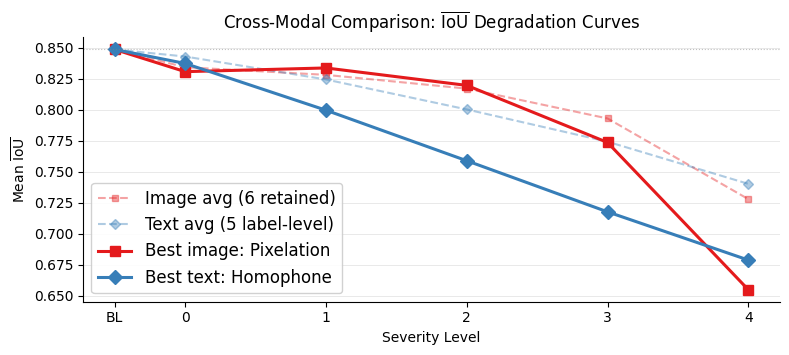

In [20]:
fig, ax = plt.subplots(figsize=(8, 3.65))

img_avg_vals = [bl_overall] + [img_ret_agg.loc[s, 'img_ret_mean'] for s in range(5)]
txt_avg_vals = [bl_overall] + [txt_agg.loc[s, 'txt_mean'] for s in range(5)]

ax.plot(x_pos, img_avg_vals, marker='s', markersize=5, linewidth=1.5,
        color=MODALITY_COLORS['Image'], alpha=0.4, linestyle='--',
        label='Image avg (6 retained)')
ax.plot(x_pos, txt_avg_vals, marker='D', markersize=5, linewidth=1.5,
        color=MODALITY_COLORS['Text'], alpha=0.4, linestyle='--',
        label='Text avg (5 label-level)')

img_best_vals = [bl_overall] + [best_img_curve[s] for s in range(5)]
txt_best_vals = [bl_overall] + [best_txt_curve[s] for s in range(5)]

ax.plot(x_pos, img_best_vals, marker='s', markersize=7, linewidth=2.2,
        color=MODALITY_COLORS['Image'],
        label=f'Best image: {IMG_NICE_NAMES.get(best_img_name, best_img_name)}')
ax.plot(x_pos, txt_best_vals, marker='D', markersize=7, linewidth=2.2,
        color=MODALITY_COLORS['Text'],
        label=f'Best text: {TXT_NICE_NAMES.get(best_txt_name, best_txt_name)}')

ax.axhline(bl_overall, color='grey', ls=':', lw=0.8, alpha=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Severity Level')
ax.set_ylabel('Mean $\\overline{\\mathrm{IoU}}$')
ax.set_title('Cross-Modal Comparison: $\\overline{\\mathrm{IoU}}$ Degradation Curves')
ax.legend(loc='lower left', fontsize=12, framealpha=0.9)
style_ax(ax)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_crossmodal_degradation_curves.pdf'),
            bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_crossmodal_degradation_curves.png'),
            bbox_inches='tight', dpi=300)
plt.show()

### Bar Chart -- IoU Drop per Modality at S4

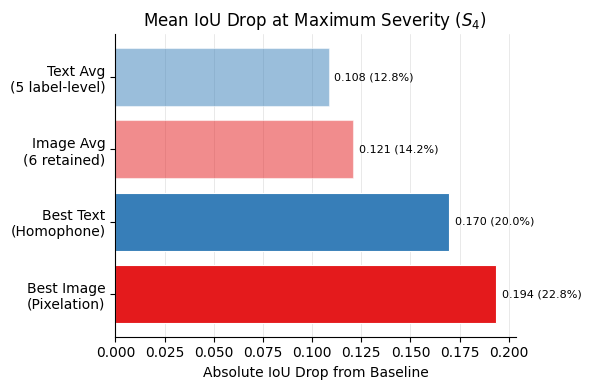

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))

labels = [
    f'Best Image\n({IMG_NICE_NAMES.get(best_img_name)})',
    f'Best Text\n({TXT_NICE_NAMES.get(best_txt_name)})',
    'Image Avg\n(6 retained)',
    'Text Avg\n(5 label-level)',
]
drops = [
    bl_overall - best_img_curve[4],
    bl_overall - best_txt_curve[4],
    bl_overall - img_ret_agg.loc[4, 'img_ret_mean'],
    bl_overall - txt_agg.loc[4, 'txt_mean'],
]
colors = [
    MODALITY_COLORS['Image'], MODALITY_COLORS['Text'],
    MODALITY_COLORS['Image'], MODALITY_COLORS['Text'],
]
alphas = [1.0, 1.0, 0.5, 0.5]

bars = ax.barh(labels, drops, color=colors, edgecolor='white', linewidth=0.8)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)

for bar, drop in zip(bars, drops):
    pct = drop / bl_overall * 100
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{drop:.3f} ({pct:.1f}%)', va='center', fontsize=8)

ax.set_xlabel('Absolute IoU Drop from Baseline')
ax.set_title('Mean IoU Drop at Maximum Severity ($S_4$)')
style_ax(ax)
ax.xaxis.grid(True, which='major', ls='-', lw=0.4, alpha=0.5)
ax.yaxis.grid(False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_crossmodal_drop_bar.pdf'),
            bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_crossmodal_drop_bar.png'),
            bbox_inches='tight', dpi=300)
plt.show()

### Combined Ranking -- All 11 Retained Corruptions at S4

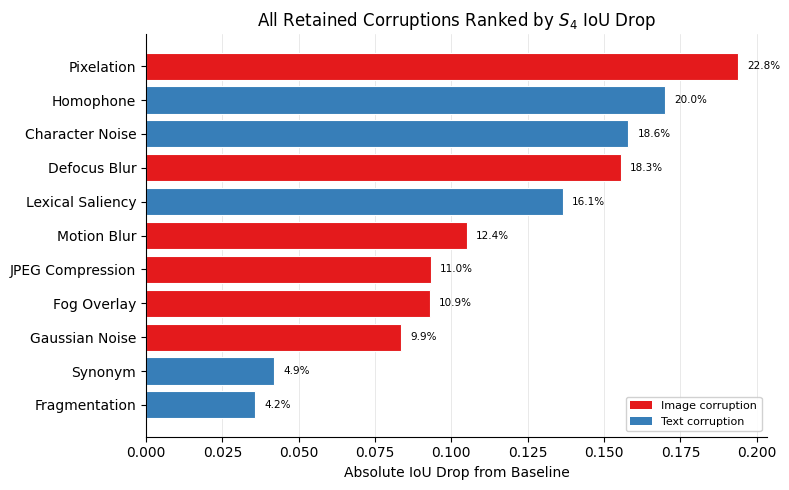

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_df = combined_s4.sort_values('abs_drop', ascending=True).copy()  # ascending so largest at top
y_labels = [f'{row.nice_name}' for _, row in plot_df.iterrows()]
bar_colors = [MODALITY_COLORS[row.modality] for _, row in plot_df.iterrows()]

bars = ax.barh(y_labels, plot_df['abs_drop'], color=bar_colors,
               edgecolor='white', linewidth=0.8)

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{row.pct_drop:.1f}%', va='center', fontsize=7.5)

legend_handles = [
    Patch(facecolor=MODALITY_COLORS['Image'], label='Image corruption'),
    Patch(facecolor=MODALITY_COLORS['Text'], label='Text corruption'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8, framealpha=0.9)

ax.set_xlabel('Absolute IoU Drop from Baseline')
ax.set_title('All Retained Corruptions Ranked by $S_4$ IoU Drop')
style_ax(ax)
ax.xaxis.grid(True, which='major', ls='-', lw=0.4, alpha=0.5)
ax.yaxis.grid(False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_combined_ranking_bar.pdf'),
            bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_combined_ranking_bar.png'),
            bbox_inches='tight', dpi=300)
plt.show()

### Relative Degradation Curves -- Modality Comparison

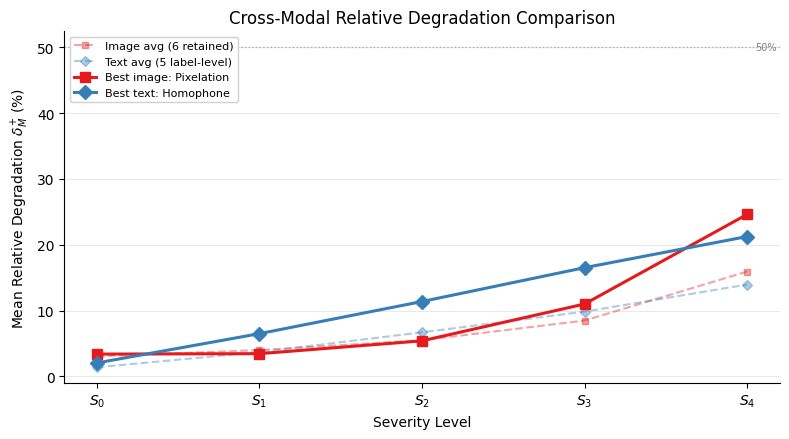

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(range(5), [img_ret_reldeg[s] for s in range(5)],
        marker='s', markersize=5, linewidth=1.5,
        color=MODALITY_COLORS['Image'], alpha=0.4, linestyle='--',
        label='Image avg (6 retained)')
ax.plot(range(5), [txt_reldeg[s] for s in range(5)],
        marker='D', markersize=5, linewidth=1.5,
        color=MODALITY_COLORS['Text'], alpha=0.4, linestyle='--',
        label='Text avg (5 label-level)')

ax.plot(range(5), [best_img_reldeg.get(s, 0) for s in range(5)],
        marker='s', markersize=7, linewidth=2.2,
        color=MODALITY_COLORS['Image'],
        label=f'Best image: {IMG_NICE_NAMES.get(best_img_name)}')
ax.plot(range(5), [best_txt_reldeg.get(s, 0) for s in range(5)],
        marker='D', markersize=7, linewidth=2.2,
        color=MODALITY_COLORS['Text'],
        label=f'Best text: {TXT_NICE_NAMES.get(best_txt_name)}')

ax.axhline(50, color='grey', ls=':', lw=1.0, alpha=0.6)
ax.text(4.05, 50, '50%', va='center', fontsize=7, color='grey')

ax.set_xticks(range(5))
ax.set_xticklabels([f'$S_{s}$' for s in range(5)])
ax.set_xlabel('Severity Level')
ax.set_ylabel('Mean Relative Degradation $\\delta_M^{+}$ (%)')
ax.set_title('Cross-Modal Relative Degradation Comparison')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
style_ax(ax)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_crossmodal_reldeg_curves.pdf'),
            bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_crossmodal_reldeg_curves.png'),
            bbox_inches='tight', dpi=300)
plt.show()

## Scene-Type Breakdown

In [24]:
print('=== Mean IoU at S4 by Modality × Scene Type ===')
print(f'{"Scene Type":<18} {"Image (ret.)":>13} {"Text":>10} {"Gap (Img-Txt)":>14}')
print('-' * 60)

for st in SCENE_ORDER:
    img_val = df_img_ret[(df_img_ret.severity == 4) & (df_img_ret.scene_type == st)]['IoU'].mean()
    txt_val = df_txt[(df_txt.severity == 4) & (df_txt.scene_type == st)]['IoU'].mean()
    gap = img_val - txt_val
    print(f'{st:<18} {img_val:>13.4f} {txt_val:>10.4f} {gap:>+13.4f}')

=== Mean IoU at S4 by Modality × Scene Type ===
Scene Type          Image (ret.)       Text  Gap (Img-Txt)
------------------------------------------------------------
Isolated                  0.8443     0.8792       -0.0349
Clustered                 0.6963     0.7239       -0.0276
Mixed                     0.6435     0.6180       +0.0255


In [25]:
print('\n=== Mean Relative Degradation (%) at S4 by Modality × Scene Type ===')
print(f'{"Scene Type":<18} {"Image (ret.)":>13} {"Text":>10} {"Gap":>10}')
print('-' * 55)

for st in SCENE_ORDER:
    img_val = df_img_ret[(df_img_ret.severity == 4) & (df_img_ret.scene_type == st)]['rel_deg_pct'].mean()
    txt_val = df_txt[(df_txt.severity == 4) & (df_txt.scene_type == st)]['rel_deg_pct'].mean()
    gap = img_val - txt_val
    print(f'{st:<18} {img_val:>12.1f}% {txt_val:>9.1f}% {gap:>+9.1f}%')


=== Mean Relative Degradation (%) at S4 by Modality × Scene Type ===
Scene Type          Image (ret.)       Text        Gap
-------------------------------------------------------
Isolated                    9.6%       5.2%      +4.5%
Clustered                  18.6%      14.7%      +3.9%
Mixed                      19.6%      22.1%      -2.5%


In [26]:
print(f'\n=== Best-in-Modality IoU at S4 by Scene Type ===')
print(f'{"Scene Type":<15} {"BL":>7} '
      f'{IMG_NICE_NAMES.get(best_img_name):>15} '
      f'{TXT_NICE_NAMES.get(best_txt_name):>15} {"Gap":>10}')
print('-' * 68)

for st in SCENE_ORDER:
    base = bl_means[st]
    img_val = df_img_all[
        (df_img_all.corruption == best_img_name) &
        (df_img_all.severity == 4) &
        (df_img_all.scene_type == st)
    ]['IoU'].mean()
    txt_val = df_txt[
        (df_txt.corruption == best_txt_name) &
        (df_txt.severity == 4) &
        (df_txt.scene_type == st)
    ]['IoU'].mean()
    gap = img_val - txt_val
    print(f'{st:<15} {base:>7.3f} {img_val:>15.3f} {txt_val:>15.3f} {gap:>+9.3f}')


=== Best-in-Modality IoU at S4 by Scene Type ===
Scene Type           BL      Pixelation       Homophone        Gap
--------------------------------------------------------------------
Isolated          0.923           0.781           0.854    -0.073
Clustered         0.841           0.624           0.658    -0.035
Mixed             0.782           0.560           0.525    +0.036


### Scene-Type × Modality Bar Chart at S4

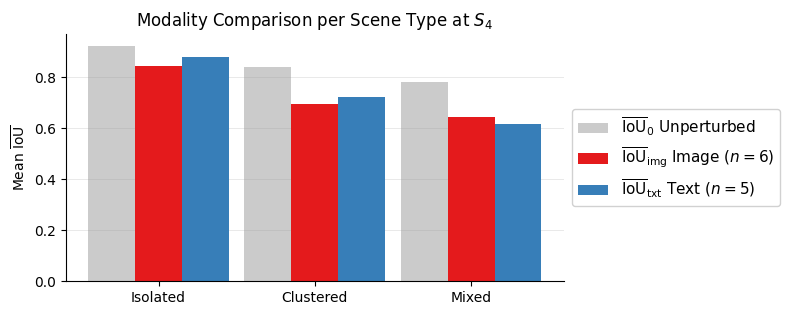

In [27]:
fig, ax = plt.subplots(figsize=(8, 3.25))

x = np.arange(len(SCENE_ORDER))
width = 0.3

img_vals_scene = [df_img_ret[(df_img_ret.severity == 4) &
                              (df_img_ret.scene_type == st)]['IoU'].mean()
                  for st in SCENE_ORDER]
txt_vals_scene = [df_txt[(df_txt.severity == 4) &
                          (df_txt.scene_type == st)]['IoU'].mean()
                  for st in SCENE_ORDER]
bl_vals_scene = [bl_means[st] for st in SCENE_ORDER]

ax.bar(x - width, bl_vals_scene, width, label='$\\overline{\\mathrm{IoU}}_0$ Unperturbed', color='#999999', alpha=0.5)
ax.bar(x,         img_vals_scene, width, label='$\\overline{\\mathrm{IoU}}_{\\mathrm{img}}$ Image ($n=6$)',
       color=MODALITY_COLORS['Image'])
ax.bar(x + width, txt_vals_scene, width, label='$\\overline{\\mathrm{IoU}}_{\\mathrm{txt}}$ Text ($n=5$)',
       color=MODALITY_COLORS['Text'])

ax.set_xticks(x)
ax.set_xticklabels(SCENE_ORDER)
ax.set_ylabel('Mean $\\overline{\\mathrm{IoU}}$')
ax.set_title('Modality Comparison per Scene Type at $S_4$')
ax.legend(fontsize=11, framealpha=0.9,
          loc='center left', bbox_to_anchor=(1.0, 0.5))
style_ax(ax)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_crossmodal_scenetype_bar.pdf'),
            bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_crossmodal_scenetype_bar.png'),
            bbox_inches='tight', dpi=300)
plt.show()

### Faceted Degradation Curves -- per Scene Type

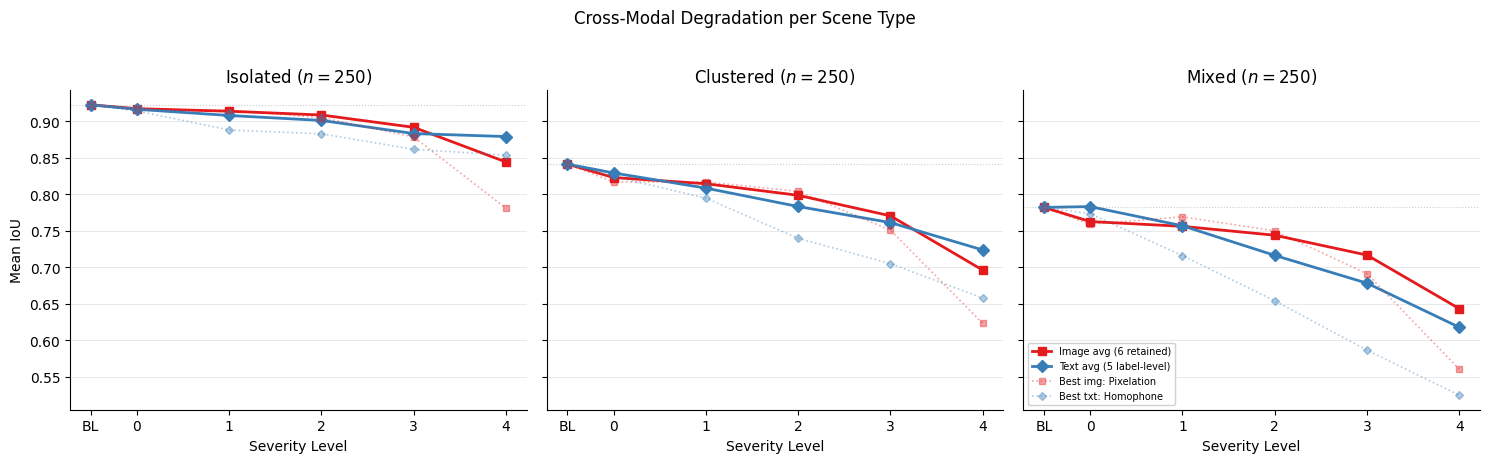

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, st in zip(axes, SCENE_ORDER):
    scene_bl = bl_means[st]

    # Image retained avg
    img_sub = df_img_ret[df_img_ret.scene_type == st].groupby('severity')['IoU'].mean()
    vals_img = [scene_bl] + [img_sub[s] for s in range(5)]
    ax.plot(x_pos, vals_img, marker='s', markersize=6, linewidth=2,
            color=MODALITY_COLORS['Image'], label='Image avg (6 retained)')

    # Text avg
    txt_sub = df_txt[df_txt.scene_type == st].groupby('severity')['IoU'].mean()
    vals_txt = [scene_bl] + [txt_sub[s] for s in range(5)]
    ax.plot(x_pos, vals_txt, marker='D', markersize=6, linewidth=2,
            color=MODALITY_COLORS['Text'], label='Text avg (5 label-level)')

    # Best-in-modality for this scene
    img_best_sub = df_img_all[
        (df_img_all.corruption == best_img_name) & (df_img_all.scene_type == st)
    ].groupby('severity')['IoU'].mean()
    txt_best_sub = df_txt[
        (df_txt.corruption == best_txt_name) & (df_txt.scene_type == st)
    ].groupby('severity')['IoU'].mean()

    vals_img_best = [scene_bl] + [img_best_sub[s] for s in range(5)]
    vals_txt_best = [scene_bl] + [txt_best_sub[s] for s in range(5)]

    ax.plot(x_pos, vals_img_best, marker='s', markersize=4, linewidth=1.2,
            color=MODALITY_COLORS['Image'], alpha=0.4, linestyle=':',
            label=f'Best img: {IMG_NICE_NAMES.get(best_img_name)}')
    ax.plot(x_pos, vals_txt_best, marker='D', markersize=4, linewidth=1.2,
            color=MODALITY_COLORS['Text'], alpha=0.4, linestyle=':',
            label=f'Best txt: {TXT_NICE_NAMES.get(best_txt_name)}')

    ax.axhline(scene_bl, color='grey', ls=':', lw=0.8, alpha=0.4)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel('Severity Level')
    ax.set_title(f'{st} ($n = 250$)')
    style_ax(ax)

axes[0].set_ylabel('Mean IoU')
axes[2].legend(loc='lower left', fontsize=7, framealpha=0.9)

fig.suptitle('Cross-Modal Degradation per Scene Type', fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_crossmodal_faceted_scene.pdf'),
            bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_crossmodal_faceted_scene.png'),
            bbox_inches='tight', dpi=300)
plt.show()

## Per-Sample Paired Analysis

In [29]:
img_per_sample = df_img_all[
    (df_img_all.corruption == best_img_name) & (df_img_all.severity == 4)
][['sample_id', 'scene_type', 'IoU', 'baseline_iou']].rename(columns={'IoU': 'iou_img'})

txt_per_sample = df_txt[
    (df_txt.corruption == best_txt_name) & (df_txt.severity == 4)
][['sample_id', 'scene_type', 'IoU']].rename(columns={'IoU': 'iou_txt'})

paired = img_per_sample.merge(txt_per_sample, on=['sample_id', 'scene_type'])
paired['img_wins'] = paired['iou_img'] < paired['iou_txt']  # lower IoU = more damage
paired['txt_wins'] = paired['iou_txt'] < paired['iou_img']
paired['tie'] = paired['iou_img'] == paired['iou_txt']

print(f'Paired samples: {len(paired)}')
print(f'  Image corruption more damaging: {paired.img_wins.sum()} '
      f'({100 * paired.img_wins.mean():.1f}%)')
print(f'  Text corruption more damaging:  {paired.txt_wins.sum()} '
      f'({100 * paired.txt_wins.mean():.1f}%)')
print(f'  Ties:                           {paired.tie.sum()}')

Paired samples: 750
  Image corruption more damaging: 511 (68.1%)
  Text corruption more damaging:  239 (31.9%)
  Ties:                           0


In [30]:
print('\n=== Per-Sample Win Rate at S4 by Scene Type ===')
for st in SCENE_ORDER:
    sub = paired[paired.scene_type == st]
    print(f'{st:<15}: Image wins {sub.img_wins.sum():>3}/{len(sub)}'
          f' ({100*sub.img_wins.mean():.1f}%),  '
          f'Text wins {sub.txt_wins.sum():>3}/{len(sub)}'
          f' ({100*sub.txt_wins.mean():.1f}%)')


=== Per-Sample Win Rate at S4 by Scene Type ===
Isolated       : Image wins 201/250 (80.4%),  Text wins  49/250 (19.6%)
Clustered      : Image wins 174/250 (69.6%),  Text wins  76/250 (30.4%)
Mixed          : Image wins 136/250 (54.4%),  Text wins 114/250 (45.6%)


### Scatter -- Per-Sample IoU (Image vs. Text) at S4

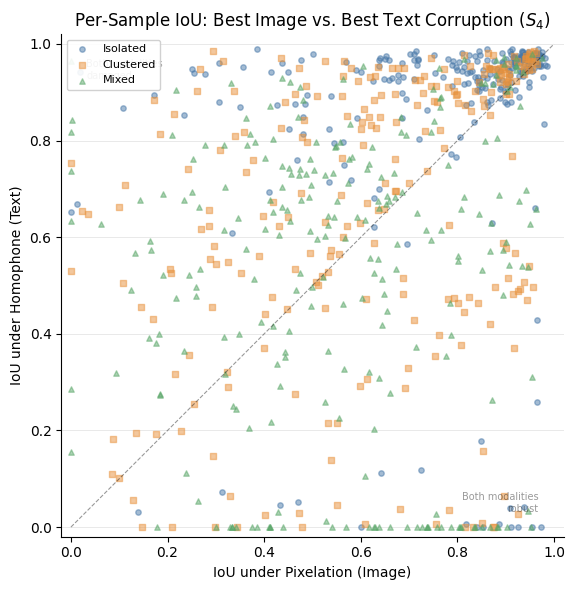

In [31]:
fig, ax = plt.subplots(figsize=(6, 6))

for st in SCENE_ORDER:
    sub = paired[paired.scene_type == st]
    ax.scatter(sub.iou_img, sub.iou_txt, s=15, alpha=0.5,
               color=SCENE_COLORS[st], marker=SCENE_MARKERS[st], label=st)

ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4)

ax.set_xlabel(f'IoU under {IMG_NICE_NAMES.get(best_img_name)} (Image)')
ax.set_ylabel(f'IoU under {TXT_NICE_NAMES.get(best_txt_name)} (Text)')
ax.set_title('Per-Sample IoU: Best Image vs. Best Text Corruption ($S_4$)')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.legend(fontsize=8, framealpha=0.9)
style_ax(ax)

ax.text(0.05, 0.95, 'Both modalities\ndamaged', fontsize=7, alpha=0.4,
        transform=ax.transAxes, va='top')
ax.text(0.95, 0.05, 'Both modalities\nrobust', fontsize=7, alpha=0.4,
        transform=ax.transAxes, ha='right')

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_crossmodal_scatter_paired.pdf'),
            bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_crossmodal_scatter_paired.png'),
            bbox_inches='tight', dpi=300)
plt.show()

## Complementarity Analysis

In [32]:
RELDEG_THRESH = 50.0  # percent

img_success_s4 = df_img_all[
    (df_img_all.corruption == best_img_name) & (df_img_all.severity == 4)
].copy()
img_success_s4['success'] = img_success_s4['rel_deg_pct'] >= RELDEG_THRESH

txt_success_s4 = df_txt[
    (df_txt.corruption == best_txt_name) & (df_txt.severity == 4)
].copy()
txt_success_s4['success'] = txt_success_s4['rel_deg_pct'] >= RELDEG_THRESH

img_success_ids = set(img_success_s4[img_success_s4.success].apply(
    lambda r: (r.scene_type, r.sample_id), axis=1))
txt_success_ids = set(txt_success_s4[txt_success_s4.success].apply(
    lambda r: (r.scene_type, r.sample_id), axis=1))
both_success = img_success_ids & txt_success_ids
either_success = img_success_ids | txt_success_ids

print(f'=== Attack Success at S4 (rel. degradation >= {RELDEG_THRESH}%) ===')
print(f'  Image only:     {len(img_success_ids - txt_success_ids)}')
print(f'  Text only:      {len(txt_success_ids - img_success_ids)}')
print(f'  Both:           {len(both_success)}')
print(f'  Either:         {len(either_success)} / 750 = {100*len(either_success)/750:.1f}%')
print(f'  Neither:        {750 - len(either_success)}')
print(f'\n  Jaccard overlap: {len(both_success) / max(1, len(either_success)):.3f}')

=== Attack Success at S4 (rel. degradation >= 50.0%) ===
  Image only:     98
  Text only:      111
  Both:           32
  Either:         241 / 750 = 32.1%
  Neither:        509

  Jaccard overlap: 0.133


In [33]:
print('\n=== Complementarity across thresholds ===')
print(f'{"Thresh":>8} {"Img":>6} {"Txt":>6} {"Both":>6} {"Either":>7} '
      f'{"Coverage":>9} {"Jaccard":>8}')
print('-' * 55)

for thresh in [25, 33, 50, 75]:
    i_ids = set(img_success_s4[img_success_s4.rel_deg_pct >= thresh].apply(
        lambda r: (r.scene_type, r.sample_id), axis=1))
    t_ids = set(txt_success_s4[txt_success_s4.rel_deg_pct >= thresh].apply(
        lambda r: (r.scene_type, r.sample_id), axis=1))
    both = i_ids & t_ids
    either = i_ids | t_ids
    print(f'{thresh:>7}% {len(i_ids):>6} {len(t_ids):>6} {len(both):>6} '
          f'{len(either):>7} {100*len(either)/750:>8.1f}% '
          f'{len(both)/max(1,len(either)):>8.3f}')


=== Complementarity across thresholds ===
  Thresh    Img    Txt   Both  Either  Coverage  Jaccard
-------------------------------------------------------
     25%    299    229    106     422     56.3%    0.251
     33%    229    198     73     354     47.2%    0.206
     50%    130    143     32     241     32.1%    0.133
     75%     40     91      6     125     16.7%    0.048


In [34]:
img_best_per_sample = df_img_ret[df_img_ret.severity == 4]\
    .groupby(['scene_type', 'sample_id'])\
    .agg(iou_img=('IoU', 'min'), baseline_iou=('baseline_iou', 'first'))\
    .reset_index()
img_best_per_sample['rel_deg_pct'] = (
    (img_best_per_sample.baseline_iou - img_best_per_sample.iou_img)
    / img_best_per_sample.baseline_iou * 100
).clip(lower=0)

txt_best_per_sample = df_txt[df_txt.severity == 4]\
    .groupby(['scene_type', 'sample_id'])\
    .agg(iou_txt=('IoU', 'min'), baseline_iou=('baseline_iou', 'first'))\
    .reset_index()
txt_best_per_sample['rel_deg_pct'] = (
    (txt_best_per_sample.baseline_iou - txt_best_per_sample.iou_txt)
    / txt_best_per_sample.baseline_iou * 100
).clip(lower=0)

print(f'Per-sample best image: {len(img_best_per_sample)} samples')
print(f'Per-sample best text:  {len(txt_best_per_sample)} samples')

print('\n=== Complementarity across thresholds (per-sample best) ===')
print(f'{"Thresh":>8} {"Img":>6} {"Txt":>6} {"Both":>6} {"Either":>7} '
      f'{"Coverage":>9} {"Jaccard":>8}')
print('-' * 55)

for thresh in [25, 33, 50, 75]:
    i_ids = set(img_best_per_sample[img_best_per_sample.rel_deg_pct >= thresh].apply(
        lambda r: (r.scene_type, r.sample_id), axis=1))
    t_ids = set(txt_best_per_sample[txt_best_per_sample.rel_deg_pct >= thresh].apply(
        lambda r: (r.scene_type, r.sample_id), axis=1))
    both = i_ids & t_ids
    either = i_ids | t_ids
    print(f'{thresh:>7}% {len(i_ids):>6} {len(t_ids):>6} {len(both):>6} '
          f'{len(either):>7} {100*len(either)/750:>8.1f}% '
          f'{len(both)/max(1,len(either)):>8.3f}')

Per-sample best image: 750 samples
Per-sample best text:  750 samples

=== Complementarity across thresholds (per-sample best) ===
  Thresh    Img    Txt   Both  Either  Coverage  Jaccard
-------------------------------------------------------
     25%    389    416    260     545     72.7%    0.477
     33%    315    389    203     501     66.8%    0.405
     50%    188    313    105     396     52.8%    0.265
     75%     64    220     34     250     33.3%    0.136


## Efficiency Comparison

In [35]:
img_has_tokens = 'token_count' in df_img_all.columns
txt_has_tokens = 'token_count' in df_txt.columns
img_has_runtime = 'runtime_seconds' in df_img_all.columns
txt_has_runtime = 'runtime_seconds' in df_txt.columns

print(f'Token count available -- Image: {img_has_tokens}, Text: {txt_has_tokens}')
print(f'Runtime available    -- Image: {img_has_runtime}, Text: {txt_has_runtime}')

Token count available -- Image: True, Text: True
Runtime available    -- Image: True, Text: True


In [36]:
if img_has_tokens and txt_has_tokens:
    print('=== Mean Visible Token Count at S4 ===')
    img_tok = df_img_ret[df_img_ret.severity == 4]['token_count'].mean()
    txt_tok = df_txt[df_txt.severity == 4]['token_count'].mean()
    bl_tok = bl.get('token_count', pd.Series()).mean() if 'token_count' in bl.columns else np.nan

    print(f'  Baseline:         {bl_tok:.1f}')
    print(f'  Image (ret.) S4:  {img_tok:.1f}  (Δ = {img_tok - bl_tok:+.1f})')
    print(f'  Text S4:          {txt_tok:.1f}  (Δ = {txt_tok - bl_tok:+.1f})')

=== Mean Visible Token Count at S4 ===
  Baseline:         103.3
  Image (ret.) S4:  88.7  (Δ = -14.6)
  Text S4:          100.7  (Δ = -2.6)


In [38]:
if img_has_tokens and txt_has_tokens:
        print('\n=== Mean Visible Token Count per Severity ===')
    print(f'{"Sev":<5} {"Image (ret.)":>13} {"Text":>10}')
    print('-' * 30)
    for s in range(5):
        it = df_img_ret[df_img_ret.severity == s]['token_count'].mean()
        tt = df_txt[df_txt.severity == s]['token_count'].mean()
        print(f'{s:<5} {it:>13.1f} {tt:>10.1f}')

IndentationError: unindent does not match any outer indentation level (<string>, line 3)

In [ ]:
print('=' * 70)
print('CROSS-MODAL COMPARISON -- KEY NUMBERS FOR EVALUATION CHAPTER')
print('=' * 70)

print(f'\nBaseline mean IoU: {bl_overall:.3f}')

print(f'\n--- Modality-level at S4 ---')
img_s4_mean = img_ret_agg.loc[4, 'img_ret_mean']
txt_s4_mean = txt_agg.loc[4, 'txt_mean']
print(f'Image (6 ret.) mean IoU: {img_s4_mean:.3f} '
      f'(drop = {bl_overall - img_s4_mean:.3f}, '
      f'{(bl_overall - img_s4_mean)/bl_overall*100:.1f}%)')
print(f'Text (5 label) mean IoU: {txt_s4_mean:.3f} '
      f'(drop = {bl_overall - txt_s4_mean:.3f}, '
      f'{(bl_overall - txt_s4_mean)/bl_overall*100:.1f}%)')

print(f'\n--- Best-in-modality at S4 ---')
print(f'Best image: {IMG_NICE_NAMES.get(best_img_name)} '
      f'(IoU = {best_img_curve[4]:.3f}, drop = {bl_overall - best_img_curve[4]:.3f}, '
      f'{(bl_overall - best_img_curve[4])/bl_overall*100:.1f}%)')
print(f'Best text:  {TXT_NICE_NAMES.get(best_txt_name)} '
      f'(IoU = {best_txt_curve[4]:.3f}, drop = {bl_overall - best_txt_curve[4]:.3f}, '
      f'{(bl_overall - best_txt_curve[4])/bl_overall*100:.1f}%)')

print(f'\n--- Per-sample win rates (best vs best at S4) ---')
print(f'Image more damaging: {100*paired.img_wins.mean():.1f}%')
print(f'Text more damaging:  {100*paired.txt_wins.mean():.1f}%')

print(f'\n--- Complementarity (50% threshold) ---')
print(f'Union coverage: {100*len(either_success)/750:.1f}%')
print(f'Jaccard:        {len(both_success)/max(1,len(either_success)):.3f}')